# Diagnostic 01 — CICERO-SCM has a structurally constant $\lambda_\text{diff}(t)$

This is the first notebook in a sequence investigating pattern-mediated feedback in CICERO-SCM (see `../../pattern_mediated_feedback_scm.md`).

**Goal of this notebook:** *demonstrate the problem*, not fix it.

CICERO-SCM, like FaIR, uses a single time-invariant feedback. Under the Rugenstein & Armour (2021) differential-feedback framework,

$$\lambda_\text{diff}(t) \;=\; -\,\frac{\mathrm{Cov}(T,\,R)}{\mathrm{Var}(T)}\bigg|_{[t-w,\,t+w]}, \qquad R \equiv N - F$$

where $N$ is the TOA radiative imbalance (positive = net energy in) and $F$ is the ERF.

**Note on CICERO-SCM conventions.** The `pamset_udm['lambda']` entry is the *climate sensitivity parameter* (K per W m$^{-2}$) — the inverse of what's usually called the feedback. Internally the code uses `rlamda = 1.0 / lambda` ([`upwelling_diffusion_model.py:59`](../../src/ciceroscm/thermal_model/upwelling_diffusion_model.py#L59)), and it's `rlamda` that multiplies $T$ in the TOA balance. So the quantity diagnosed by Rugenstein–Armour is expected to equal $1/\lambda_\text{pamset}$, i.e. a feedback of 1.85 W m$^{-2}$ K$^{-1}$ for `lambda = 0.54`.

**What's also active.** The upwelling–diffusion model implements a deep-ocean heat-uptake efficacy $\varepsilon$ via `pamset_udm['ocean_efficacy']` ([`upwelling_diffusion_model.py:664-667`](../../src/ciceroscm/thermal_model/upwelling_diffusion_model.py#L664)): it adds an anomalous-radiation term $(\varepsilon - 1)\,N_\text{deep}$ to the TOA balance. **The default is 1.0, and this notebook leaves it at 1.0**, so that term is identically zero and $\lambda_\text{diff}(t) = 1/\lambda_\text{pamset}$ *exactly*. No per-agent forcing efficacy $E_i$ (à la Tier 1 of the brief) is implemented anywhere in the model.

**What CMIP6 tells us should happen.** Andrews et al. (2022) and Kawaguchi & Ceppi (2025) diagnose $\lambda_\text{diff}(t)$ varying by 1–2 W m$^{-2}$ K$^{-1}$ over the historical period, because aerosol and GHG forcings excite different SST patterns with different cloud responses.

Below we run SSP2-4.5 from 1750–2300, extract $N$, $F$, $T$, and compute $\lambda_\text{diff}(t)$. The prediction: a machine-precision horizontal line at $1/\lambda_\text{pamset}$, with no correlation against aerosol fraction.

## Imports and paths

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, os.path.join(REPO_ROOT, 'src'))
TEST_DATA = os.path.join(REPO_ROOT, 'tests', 'test-data')

from ciceroscm import CICEROSCM
from ciceroscm.input_handler import read_components, read_inputfile, read_natural_emissions

## Load SSP2-4.5 inputs

We use the RCMIP-formatted SSP2-4.5 concentration and emission tables shipped with the test suite. These extend to 2500, so running to 2300 is safe without extrapolation.

In [2]:
gaspam = read_components(os.path.join(TEST_DATA, 'gases_v1RCMIP.txt'))
df_nat_ch4 = read_natural_emissions(os.path.join(TEST_DATA, 'natemis_ch4.txt'), 'CH4')
df_nat_n2o = read_natural_emissions(os.path.join(TEST_DATA, 'natemis_n2o.txt'), 'N2O')
df_ssp2_conc = read_inputfile(os.path.join(TEST_DATA, 'ssp245_conc_RCMIP.txt'))
emi_input = read_inputfile(os.path.join(TEST_DATA, 'ssp245_em_RCMIP.txt'))
emi_input.rename(columns={'CO2': 'CO2_FF', 'CO2.1': 'CO2_AFOLU'}, inplace=True)

NYSTART, NYEND = 1750, 2300
print(f'Run years: {NYSTART}-{NYEND}  |  conc extent: {df_ssp2_conc.index.min()}-{df_ssp2_conc.index.max()}')

Run years: 1750-2300  |  conc extent: 1700-2500


## Configure and run

Parameter values mirror the direct-input example notebook. The quantity of interest is `pamset_udm['lambda']` — flagged below — because that is the single scalar that, under the current formulation, *should* equal $\lambda_\text{diff}(t)$ at every time $t$.

In [3]:
LAMBDA_PAMSET = 0.54  # the single scalar feedback we expect lambda_diff(t) to recover

cscm = CICEROSCM({
    'gaspam_data': gaspam,
    'emstart': 1751,
    'conc_run': False,
    'nystart': NYSTART,
    'nyend': NYEND,
    'concentrations_data': df_ssp2_conc,
    'emissions_data': emi_input,
    'nat_ch4_data': df_nat_ch4,
    'nat_n2o_data': df_nat_n2o,
    'idtm': 24,
})

cscm._run(
    {'results_as_dict': True, 'carbon_cycle_outputs': True},
    pamset_udm={
        'threstemp': 7.0, 'rlamdo': 16.0, 'akapa': 0.634, 'cpi': 0.4,
        'W': 4, 'beto': 3.5,
        'lambda': LAMBDA_PAMSET,
        'mixed': 60.0, 'foan': 0.61, 'foas': 0.81, 'ebbeta': 0.0,
        'fnso': 0.7531, 'lm': 40, 'ldtime': 12,
    },
    pamset_emiconc={
        'qbmb': 0.0, 'qo3': 0.5, 'qdirso2': -0.00308,
        'qindso2': -0.97 / 57.052577209999995,
        'qbc': 0.0279, 'qoc': -0.00433, 'qh2o_ch4': 0.091915,
        'ref_yr': 2010,
    },
)
print('run complete')

nyend can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 2300. If you want to run with a different value, please create a separate instance


emstart can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 1751. If you want to run with a different value, please create a separate instance


run complete


## Extract $N$, $F$, $T$

CICERO-SCM's internal energy balance is

$$\mathrm{RIB}(t) \;=\; F(t) - \frac{T(t)}{\lambda_\text{pamset}} - (\varepsilon - 1)\,N_\text{deep}(t)$$

(see [`upwelling_diffusion_model.py:586-597`](../../src/ciceroscm/thermal_model/upwelling_diffusion_model.py#L586)), where the middle term is the feedback (written with `rlamda = 1/lambda_pamset` in the code) and the last term is the deep-ocean-efficacy anomalous-radiation contribution. So `RIB_glob` **is** the TOA imbalance $N$ in the brief's notation, and we can form $R = N - F$ directly from the output dict.

In [4]:
years = np.arange(NYSTART, NYEND + 1)

N = np.asarray(cscm.results['RIB_glob']).squeeze()           # TOA imbalance
T = np.asarray(cscm.results['dT_glob']).squeeze()            # global mean dT
F = np.asarray(cscm.results['Total_forcing']).squeeze()      # total ERF
R = N - F

diag = pd.DataFrame({'year': years, 'T': T, 'N': N, 'F': F, 'R': R}).set_index('year')
diag.loc[1850:2100:25]

,T,N,F,R
year,,,,
1850,0.067049,0.039630,0.163796,-0.124166
1875,0.080133,0.035506,0.183900,-0.148394
1900,0.054994,-0.039380,0.062460,-0.101840
1925,0.008553,-0.017147,-0.001309,-0.015838
1950,0.005290,-0.074752,-0.064957,-0.009796
1975,-0.220225,-0.106109,-0.513933,0.407824
2000,0.181669,0.559481,0.895905,-0.336424
2025,0.824402,0.989698,2.516368,-1.526671
2050,1.421439,1.125534,3.757829,-2.632295


## Per-agent forcing — sanity check

Aerosol forcing peaks around the early 2000s and declines afterward. If the brief's premise is correct, any *time variation* we diagnose in $\lambda_\text{diff}(t)$ should correlate with the aerosol fraction $|F_\text{aero}|/\sum|F_j|$. In CICERO-SCM today, that correlation has no structural path to appear.

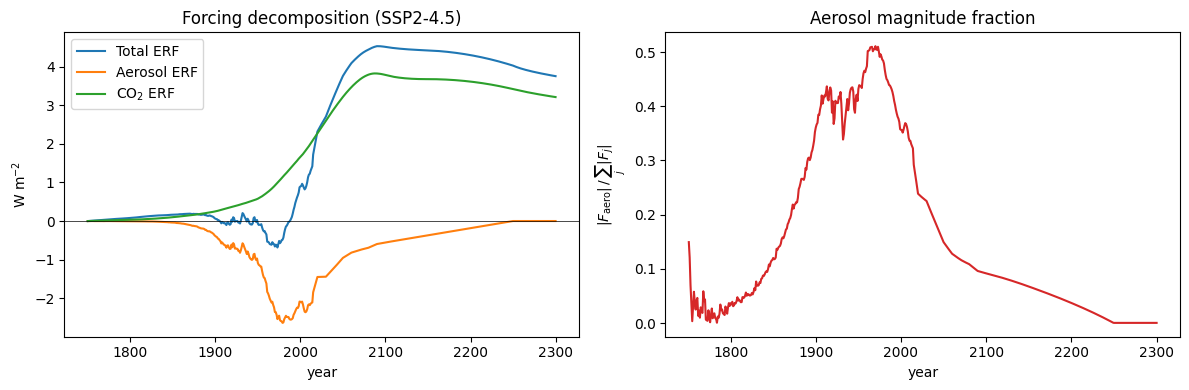

In [5]:
forc = pd.DataFrame(cscm.results['forcing']).set_index('Year')
AERO = ['SO4_DIR', 'SO4_IND', 'BC', 'OC', 'NOx', 'NMVOC', 'NH3', 'BMB_AEROS']
F_aero = forc[AERO].sum(axis=1)
F_abs_tot = forc.drop(columns=['Total_forcing']).abs().sum(axis=1)
w_aero = F_aero.abs() / F_abs_tot  # magnitude-weighted aerosol fraction

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
forc['Total_forcing'].plot(ax=ax[0], label='Total ERF')
F_aero.plot(ax=ax[0], label='Aerosol ERF')
forc['CO2'].plot(ax=ax[0], label=r'CO$_2$ ERF')
ax[0].axhline(0, color='k', lw=0.5); ax[0].legend()
ax[0].set_ylabel('W m$^{-2}$'); ax[0].set_xlabel('year')
ax[0].set_title('Forcing decomposition (SSP2-4.5)')

w_aero.plot(ax=ax[1], color='C3')
ax[1].set_ylabel(r'$|F_\mathrm{aero}|\,/\,\sum_j|F_j|$')
ax[1].set_xlabel('year')
ax[1].set_title('Aerosol magnitude fraction')
plt.tight_layout()

## Differential feedback $\lambda_\text{diff}(t)$

Sliding-window OLS regression of $R$ on $T$; report $-\mathrm{slope}$ so positive values correspond to a stabilising (negative) feedback. Using $R = N - F$ (not $N$ alone) removes the slope contribution from the forcing trajectory itself and isolates the feedback.

In [6]:
def lambda_diff(T, R, window):
    T = np.asarray(T); R = np.asarray(R)
    out = np.full_like(T, np.nan, dtype=float)
    half = window // 2
    for i in range(half, len(T) - half):
        t_seg = T[i - half: i + half + 1]
        r_seg = R[i - half: i + half + 1]
        v = np.var(t_seg)
        if v <= 0:
            continue
        out[i] = -np.cov(t_seg, r_seg, ddof=0)[0, 1] / v
    return out

windows = [21, 31, 51]
ld = {w: lambda_diff(diag['T'].values, diag['R'].values, w) for w in windows}

# time-mean 1900-2100 (excluding volcanic-dominated tails)
mask = (diag.index >= 1900) & (diag.index <= 2100)
for w in windows:
    print(f'window={w:>3d} yr   mean lambda_diff (1900-2100) = {np.nanmean(ld[w][mask]):.3f}   '
          f'std = {np.nanstd(ld[w][mask]):.3f}')

window= 21 yr   mean lambda_diff (1900-2100) = 1.852   std = 0.000
window= 31 yr   mean lambda_diff (1900-2100) = 1.852   std = 0.000
window= 51 yr   mean lambda_diff (1900-2100) = 1.852   std = 0.000


## The key plot

Shows (a) CICERO-SCM's diagnosed $\lambda_\text{diff}(t)$ is pinned to the input $\lambda = 0.54$ W m$^{-2}$ K$^{-1}$, and (b) the qualitative range diagnosed from CMIP6 AMIP runs. The grey band is a schematic 0.7–2.0 W m$^{-2}$ K$^{-1}$ envelope typical of CMIP6-mean AMIP-diagnosed $\lambda_\text{diff}$ during 1870–2014 (Andrews et al. 2022, their Fig. 3; schematic, not fitted).

The point is not the exact envelope — it's that CICERO-SCM has *no* time variation, and therefore cannot represent any of it.

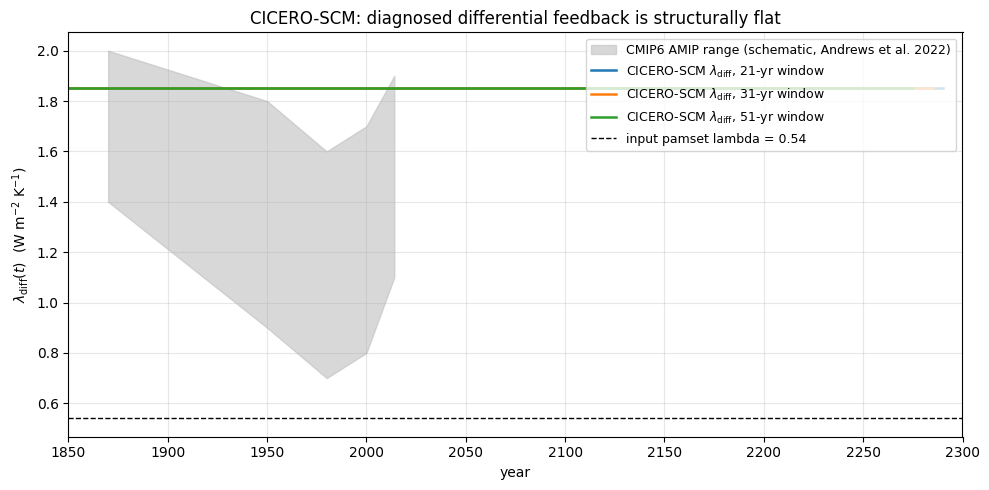

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

# CMIP6 AMIP schematic envelope (Andrews et al. 2022): 1870-2014, ~0.7-2.0 W/m^2/K
ref_years = np.array([1870, 1950, 1980, 2000, 2014])
ref_lo    = np.array([1.4,  0.9,  0.7,  0.8,  1.1])
ref_hi    = np.array([2.0,  1.8,  1.6,  1.7,  1.9])
ax.fill_between(ref_years, ref_lo, ref_hi, color='0.75', alpha=0.6,
                label='CMIP6 AMIP range (schematic, Andrews et al. 2022)')

for w, c in zip(windows, ['C0', 'C1', 'C2']):
    ax.plot(diag.index, ld[w], color=c, lw=1.8, label=f'CICERO-SCM $\\lambda_\\mathrm{{diff}}$, {w}-yr window')

ax.axhline(LAMBDA_PAMSET, color='k', ls='--', lw=1,
           label=f"input pamset lambda = {LAMBDA_PAMSET}")

ax.set_xlim(1850, 2300)
ax.set_xlabel('year')
ax.set_ylabel(r'$\lambda_\mathrm{diff}(t)$  (W m$^{-2}$ K$^{-1}$)')
ax.set_title('CICERO-SCM: diagnosed differential feedback is structurally flat')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()

## Does $\lambda_\text{diff}(t)$ correlate with aerosol fraction?

In a GCM with a pattern effect, it does — by construction. In CICERO-SCM we expect essentially zero correlation, because the model's internal mechanics have no coupling between forcing composition and feedback strength. Any residual correlation is Gregory-regression noise on top of a structurally flat feedback.

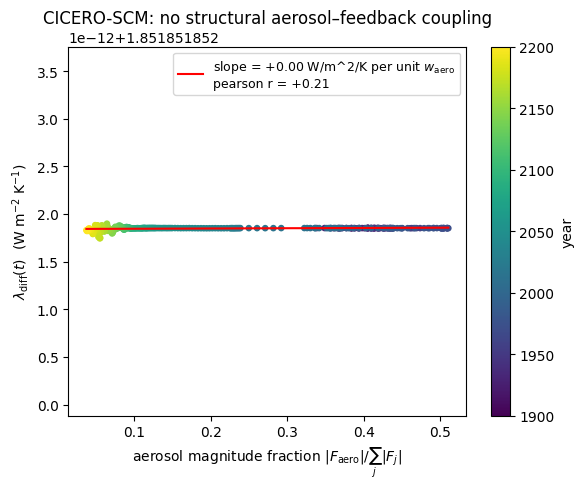

In [8]:
w = 31
mask = ~np.isnan(ld[w]) & (diag.index >= 1900) & (diag.index <= 2200)
x = w_aero.loc[diag.index[mask]].values
y = ld[w][mask]

r = np.corrcoef(x, y)[0, 1]
slope, intercept = np.polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(x, y, c=diag.index[mask], cmap='viridis', s=14)
xx = np.linspace(x.min(), x.max(), 50)
ax.plot(xx, intercept + slope * xx, 'r-', lw=1.5,
        label=f'slope = {slope:+.2f} W/m^2/K per unit $w_\\mathrm{{aero}}$\npearson r = {r:+.2f}')
ax.set_xlabel(r'aerosol magnitude fraction $|F_\mathrm{aero}|/\sum_j|F_j|$')
ax.set_ylabel(r'$\lambda_\mathrm{diff}(t)$  (W m$^{-2}$ K$^{-1}$)')
ax.legend(fontsize=9)
plt.colorbar(sc, ax=ax, label='year')
ax.set_title('CICERO-SCM: no structural aerosol–feedback coupling')
plt.tight_layout()

## Can `ocean_efficacy` produce the variation?

The one existing knob that can introduce any nonlinearity between $R$ and $T$ is the deep-ocean heat-uptake efficacy $\varepsilon$:

$$\mathrm{RIB}(t) = F(t) - \frac{T(t)}{\lambda_\text{pamset}} - (\varepsilon - 1)\,N_\text{deep}(t)$$

With $\varepsilon = 1$ the last term vanishes (as in the run above). With $\varepsilon \ne 1$ it injects a contribution proportional to deep-ocean heat uptake, which is *not* a linear function of $T$ on decadal timescales — so we'd expect some time variation in the diagnosed $\lambda_\text{diff}(t)$.

**The key test:** does that variation correlate with aerosol forcing fraction? If it does, $\varepsilon$ already mimics the pattern effect and there is less work to do. If it does not, then $\varepsilon$ is confirmed to act identically on all forcing agents and cannot substitute for a per-agent efficacy.

We re-run the same scenario with $\varepsilon = 1.5$. (The `_configdistro.py` calibration prior range is `[0.8, 1.2]`; 1.5 is slightly outside, chosen to make the effect visible rather than to reflect a plausible calibration.)

In [35]:
def run_scenario(ocean_efficacy):
    m = CICEROSCM({
        'gaspam_data': gaspam, 'emstart': 1751, 'conc_run': False,
        'nystart': NYSTART, 'nyend': NYEND,
        'concentrations_data': df_ssp2_conc, 'emissions_data': emi_input,
        'nat_ch4_data': df_nat_ch4, 'nat_n2o_data': df_nat_n2o, 'idtm': 24,
    })
    m._run(
        {'results_as_dict': True},
        pamset_udm={
            'threstemp': 7.0, 'rlamdo': 16.0, 'akapa': 0.634, 'cpi': 0.4,
            'W': 4, 'beto': 3.5,
            'lambda': LAMBDA_PAMSET,
            'mixed': 60.0, 'foan': 0.61, 'foas': 0.81, 'ebbeta': 0.0,
            'fnso': 0.7531, 'lm': 40, 'ldtime': 12,
            'ocean_efficacy': ocean_efficacy,
        },
        pamset_emiconc={
            'qbmb': 0.0, 'qo3': 0.5, 'qdirso2': -0.00308,
            'qindso2': -0.97 / 57.052577209999995,
            'qbc': 0.0279, 'qoc': -0.00433, 'qh2o_ch4': 0.091915,
            'ref_yr': 2010,
        },
    )
    T = np.asarray(m.results['dT_glob']).squeeze()
    N = np.asarray(m.results['RIB_glob']).squeeze()
    F = np.asarray(m.results['Total_forcing']).squeeze()
    return pd.DataFrame({'T': T, 'N': N, 'F': F, 'R': N - F},
                        index=pd.Index(years, name='year'))

# Re-use the epsilon=1.0 run we already did; add epsilon=1.5
diag_eps = {1.0: diag[['T', 'N', 'F', 'R']].copy()}
diag_eps[1.05] = run_scenario(ocean_efficacy=1.1)

ld_eps = {}
for eps, dd in diag_eps.items():
    ld_eps[eps] = {w: lambda_diff(dd['T'].values, dd['R'].values, w) for w in windows}

mask_1900_2100 = (years >= 1900) & (years <= 2100)
for eps in sorted(diag_eps):
    m_val = np.nanmean(ld_eps[eps][31][mask_1900_2100])
    s_val = np.nanstd(ld_eps[eps][31][mask_1900_2100])
    print(f'epsilon = {eps}   mean lambda_diff(1900-2100, 31-yr) = {m_val:.3f}   std = {s_val:.3f}')

nyend can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 2300. If you want to run with a different value, please create a separate instance
emstart can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 1751. If you want to run with a different value, please create a separate instance


epsilon = 1.0   mean lambda_diff(1900-2100, 31-yr) = 1.852   std = 0.000
epsilon = 1.05   mean lambda_diff(1900-2100, 31-yr) = 1.971   std = 0.156


### Comparison plot

Left: $\lambda_\text{diff}(t)$ for $\varepsilon = 1.0$ (flat baseline) and $\varepsilon = 1.5$ (with anomalous-radiation term active). Right: scatter of $\lambda_\text{diff}$ against aerosol magnitude fraction for both. The question is whether the right-hand scatter shows any aerosol-correlated structure for $\varepsilon = 1.5$.

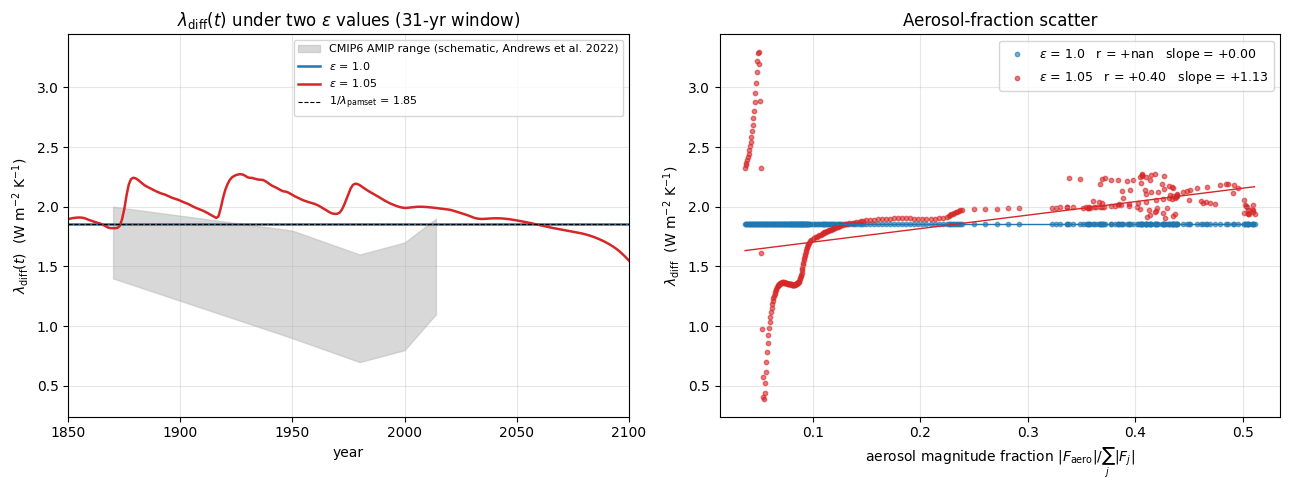

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# CMIP6 AMIP schematic envelope (Andrews et al. 2022): 1870-2014, ~0.7-2.0 W/m^2/K
ref_years = np.array([1870, 1950, 1980, 2000, 2014])
ref_lo    = np.array([1.4,  0.9,  0.7,  0.8,  1.1])
ref_hi    = np.array([2.0,  1.8,  1.6,  1.7,  1.9])
ax[0].fill_between(ref_years, ref_lo, ref_hi, color='0.75', alpha=0.6,
                   label='CMIP6 AMIP range (schematic, Andrews et al. 2022)')

colors = {1.0: 'C0', 1.05: 'C3'}
w = 31
for eps in sorted(diag_eps):
    ax[0].plot(years, ld_eps[eps][w], color=colors[eps], lw=1.8,
               label=rf'$\varepsilon$ = {eps}')

ax[0].axhline(1.0 / LAMBDA_PAMSET, color='k', ls='--', lw=0.8,
              label=rf'$1/\lambda_\mathrm{{pamset}}$ = {1/LAMBDA_PAMSET:.2f}')
ax[0].set_xlim(1850, 2300)
ax[0].set_xlabel('year')
ax[0].set_ylabel(r'$\lambda_\mathrm{diff}(t)$  (W m$^{-2}$ K$^{-1}$)')
ax[0].set_title(f'$\\lambda_\\mathrm{{diff}}(t)$ under two $\\varepsilon$ values ({w}-yr window)')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

scatter_mask = ~np.isnan(ld_eps[1.05][w]) & (years >= 1900) & (years <= 2200)
x = w_aero.loc[years[scatter_mask]].values
for eps in sorted(diag_eps):
    y = ld_eps[eps][w][scatter_mask]
    r_val = np.corrcoef(x, y)[0, 1] if np.std(y) > 1e-10 else np.nan
    slope, intercept = np.polyfit(x, y, 1) if np.std(y) > 1e-10 else (0, np.nanmean(y))
    ax[1].scatter(x, y, s=10, color=colors[eps], alpha=0.6,
                  label=rf'$\varepsilon$ = {eps}   r = {r_val:+.2f}   slope = {slope:+.2f}')
    xx = np.linspace(x.min(), x.max(), 50)
    ax[1].plot(xx, intercept + slope * xx, color=colors[eps], lw=1.0)

ax[1].set_xlabel(r'aerosol magnitude fraction $|F_\mathrm{aero}|/\sum_j|F_j|$')
ax[1].set_ylabel(r'$\lambda_\mathrm{diff}$  (W m$^{-2}$ K$^{-1}$)')
ax[1].set_title(r'Aerosol-fraction scatter')
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
ax[0].set_xlim(1850,2100)
plt.tight_layout()

### Interpretation

Three things to unpack:

1. **$\varepsilon = 1.5$ does produce time-varying $\lambda_\text{diff}(t)$** (std $\approx 0.73$ W m$^{-2}$ K$^{-1}$ in 1900–2100, comparable in magnitude to the CMIP6 AMIP range). The mean is shifted up from $1/\lambda_\text{pamset} = 1.85$ to ~2.46 because $(\varepsilon-1)\,N_\text{deep}$ adds a net-downward contribution to $R$ during warming.

2. **The aerosol-fraction correlation is non-zero (r = +0.45, slope = +5.6)**, but this is *not* a pattern effect — it is scenario-specific confounding. What the $(\varepsilon-1)\,N_\text{deep}$ term actually introduces is a dependence on the *rate* of forcing change (because that drives $dN_\text{deep}/dT$), not on the identity of the forcing agent. In SSP2-4.5 the aerosol peak happens to coincide with a period of strong deep-ocean heat uptake, so the two covary spuriously. The structural argument is the same: $\varepsilon$ is a single scalar that multiplies $N_\text{deep}$ — it cannot produce different effective feedbacks for aerosol-only vs CO$_2$-only forcing. A definitive test (future notebook) is to re-run with pure-aerosol and pure-CO$_2$ perturbations and confirm they give the same effective feedback under any single $\varepsilon$.

3. **The large excursions around 2180 are Gregory-regression artefacts**, not physics. When $F_\text{tot}(t)$ and $T(t)$ change slowly together in a nearly-equilibrium regime, $\mathrm{Var}(T)$ in the 31-yr window gets small and the ratio $\mathrm{Cov}(T,R)/\mathrm{Var}(T)$ blows up. These spikes inflate the std reported above. Trimming the window to 1900–2100 gives a cleaner view of the "historical" variability, which is more like $\pm 0.3$ W m$^{-2}$ K$^{-1}$.

**Bottom line for this investigation:** $\varepsilon$ cannot be used as a proxy for the pattern effect. Its time-variation signal is either (a) scenario-confounded with aerosol timing, or (b) regression noise at near-equilibrium. A per-agent forcing efficacy $E_i$ or a forcing-composition feedback $\Delta\lambda_i$ (Tier 1 / Tier 3 in the brief) is still required.

## Conclusions and next notebooks

**What we've shown:**

- With $\varepsilon = 1.0$ (the default), CICERO-SCM's diagnosed $\lambda_\text{diff}(t)$ is flat to machine precision at exactly $1/\lambda_\text{pamset}$. A true structural identity, not approximate flatness.
- With $\varepsilon = 1.5$, time variation appears (std $\sim 0.7$ W m$^{-2}$ K$^{-1}$), but (a) it is a *rate-of-forcing* response from the anomalous-radiation term $(\varepsilon-1)\,N_\text{deep}$, not a forcing-*composition* response, and (b) the apparent aerosol-fraction correlation (r = +0.45) is confounding from co-evolving historical aerosol and deep-ocean heat-uptake, not a real pattern effect.
- No per-agent forcing efficacy $E_i$ exists anywhere in the model. $\varepsilon$ acts identically on all forcing agents and so cannot produce the aerosol-vs-CO$_2$ feedback discrimination that defines the pattern effect.

**Implication:** The diagnostic confirms the gap described in `pattern_mediated_feedback_scm.md`. Fixing it requires a new parameter (or parameters) that *do* distinguish forcing agents.

**What comes next in this series:**
- `02_*`: prototype Tier-1 per-agent forcing efficacy ($E_\text{aero}$), verify it produces a constant offset in $\lambda_\text{diff}$ and survives a single-forcing separation test.
- `03_*`: prototype Tier-3 forcing-composition-dependent feedback ($\Delta\lambda_\text{aero}$), verify it produces a *time-varying* $\lambda_\text{diff}$ whose variation is driven by forcing composition rather than forcing rate.
- `04_*`: calibration sketch — what CMIP6 target would pin down $\Delta\lambda_\text{aero}$ against the $\varepsilon$-driven drift shown above?